In [1]:
from IPython.display import HTML, display

display(HTML('''
<style>
/* Targets Classic Jupyter Notebook */
.output_wrapper, .output {
    height: auto !important;
    max-height: none !important;
}
.output_scroll {
    box-shadow: none !important;
    -webkit-box-shadow: none !important;
    height: auto !important;
    max-height: none !important;
}

/* Targets JupyterLab */
.jp-OutputArea-child, .jp-OutputArea-output {
    max-height: none !important;
}
</style>
'''))

In [2]:
import pandas as pd
import numpy as np
import os
from IPython.display import display, Image as IPyImage, clear_output

In [3]:
def haversine_distance(lat1, lon1, lat2, lon2):
    R = 6371000  
    phi1, phi2 = np.radians(lat1), np.radians(lat2)
    delta_phi = np.radians(lat2 - lat1)
    delta_lambda = np.radians(lon2 - lon1)
    a = np.sin(delta_phi/2.0)**2 + np.cos(phi1) * np.cos(phi2) * np.sin(delta_lambda/2.0)**2
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))
    return R * c

def get_local_path(root_folder, original_linux_path):
    """
    Strips the first 4 directories from the Ubuntu path and joins with the Windows root.
    Example: /vol2/Amfitrite/OWD/obis_data_v2/HABs_part1/folder -> root_folder/HABs_part1/folder
    """
    parts = original_linux_path.strip().strip('/').split('/')
    kept_parts = parts[4:]
    return os.path.join(root_folder, *kept_parts)

def parse_user_tiles(user_input, valid_tile_dict):
    """Converts user input like '1, 3, 5' into actual folder names."""
    if not user_input.strip():
        return []
    
    selected_names = []
    raw_nums = [n.strip() for n in user_input.split(',')]
    
    for num in raw_nums:
        if num in valid_tile_dict:
            selected_names.append(valid_tile_dict[num])
        else:
            print(f"  [!] Warning: Tile '{num}' not found. Skipping.")
            
    return selected_names

In [4]:
def run_annotation_ui(root_folder, csv_path):
    if not os.path.exists(csv_path):
        print(f"Error: CSV not found at {csv_path}")
        return
        
    try:
        df = pd.read_csv(csv_path, low_memory=False)
    except UnicodeDecodeError:
        df = pd.read_csv(csv_path, encoding='latin-1', sep=';', low_memory=False)
    
    # Filename Logic
    if csv_path.endswith("_processed.csv"):
        save_path = csv_path
    else:
        save_path = csv_path.replace(".csv", "_processed.csv")
        
    # Column Initialization
    for col in ['manually_processed', 'usable', 'tiles_HABs', 'tiles_nonHABs']:
        if col not in df.columns:
            df[col] = 0 if col in ['manually_processed', 'usable'] else ""
            
    col_status = 'status'
    col_ishab = 'is_HAB'
    col_outfolder = 'output_folder'
    col_sat = 'sat_item'
    col_lat = 'decimalLatitude' if 'decimalLatitude' in df.columns else 'latitiude' # Fallback safety
    col_lon = 'decimalLongitude' if 'decimalLongitude' in df.columns else 'Longtitude'
    col_ocl = "Overall_Class"
    
    # Dynamic Clustering if missing
    if 'cluster_ID' not in df.columns:
        print("Column 'cluster_ID' not found. Generating spatial clusters dynamically...")
        df['cluster_ID'] = np.nan
        df_success = df[
            (df[col_status].astype(str).str.upper() == 'SUCCESS') & 
            (df[col_ocl].astype(str).str.lower() != 'filters removed all tiles') &
            (df[col_sat].notna()) & (df[col_sat].astype(str).str.strip() != '') &
            (df[col_outfolder].notna())
        ]
        c_count = 1
        
        # Ensure lat/lon are floats for haversine
        df[col_lat] = pd.to_numeric(df[col_lat].astype(str).str.replace(',', '.'), errors='coerce')
        df[col_lon] = pd.to_numeric(df[col_lon].astype(str).str.replace(',', '.'), errors='coerce')
        
        for idx, row in df_success.iterrows():
            if pd.notna(df.at[idx, 'cluster_ID']): continue
            mask = haversine_distance(row[col_lat], row[col_lon], df_success[col_lat], df_success[col_lon]) <= 7680
            df.loc[df_success[mask].index, 'cluster_ID'] = c_count
            c_count += 1
            
    # Find all unprocessed and valid rows
    unprocessed_mask = (df['manually_processed'] != 1) & (df['manually_processed'].astype(str).str.upper() != 'YES')
    valid_mask = (
        (df[col_status].astype(str).str.upper() == 'SUCCESS') & 
        (df[col_ocl].astype(str).str.lower() != 'filters removed all tiles') &
        (df[col_sat].notna()) & (df[col_sat].astype(str).str.strip() != '') &
        (df[col_outfolder].notna())
    )
    
    df_valid_unprocessed = df[unprocessed_mask & valid_mask]

    if df_valid_unprocessed.empty:
        print("No remaining unprocessed cases match your criteria! You are all done.")
        return

    # =====================================================================
    # NEW LOGIC: PRIORITIZE CLUSTERS WITH AT LEAST ONE 'YES'
    # =====================================================================
    # 1. Identify which valid, unprocessed rows are actually 'YES' HABs
    hab_mask = df_valid_unprocessed[col_ishab].astype(str).str.strip().str.upper() == 'YES'
    
    # 2. Get the unique cluster IDs that contain at least one YES
    hab_clusters = df_valid_unprocessed[hab_mask]['cluster_ID'].dropna().unique()
    hab_clusters_sorted = sorted(list(hab_clusters))
    
    # 3. Get the rest of the valid clusters
    all_valid_clusters = df_valid_unprocessed['cluster_ID'].dropna().unique()
    non_hab_clusters_sorted = sorted(list(set(all_valid_clusters) - set(hab_clusters_sorted)))
    
    # 4. Combine them so HAB-containing clusters are processed first
    ordered_clusters = hab_clusters_sorted + non_hab_clusters_sorted
    # =====================================================================

    # Iterate through the newly ordered clusters
    for cid in ordered_clusters:
        # Get ONLY the unprocessed entries for this cluster to avoid re-evaluating completed ones
        cluster_entries = df[(df['cluster_ID'] == cid) & valid_mask & unprocessed_mask]
        
        # Separate into HABs and Rest (No / Potential No)
        hab_indices = []
        rest_indices = []
        
        for idx in cluster_entries.index:
            if str(df.at[idx, col_ishab]).strip().upper() == 'YES':
                hab_indices.append(idx)
            else:
                rest_indices.append(idx)
                
        hab_count = len(hab_indices)
        rest_count = len(rest_indices)
        
        # =====================================================================
        # CLUSTER PREVIEW BLOCK
        # =====================================================================
        clear_output(wait=True)
        print("="*80)
        print(f"CLUSTER {cid} PREVIEW | Total Cases: {len(cluster_entries)}")
        print("="*80)
        
        for p_idx in cluster_entries.index:
            p_row = df.loc[p_idx]
            p_ishab = str(p_row[col_ishab]).strip()
            local_base_folder = get_local_path(root_folder, p_row[col_outfolder])
            img_path = os.path.join(local_base_folder, "colage.png")
            
            print(f"\n--- Database Status: {p_ishab} ---")
            if os.path.exists(img_path):
                display(IPyImage(filename=img_path))
            else:
                print(f"[!] Image not found at {img_path}")
                
        print("\n" + "="*80)
        input("Press Enter to begin annotating these cases one by one...")
        # =====================================================================
        
        # Process YES cases first, then the Rest
        case_groups = [("HAB", hab_indices), ("REST", rest_indices)]
        
        for group_label, indices in case_groups:
            if not indices:
                continue
                
            for count, idx in enumerate(indices, start=1):
                row = df.loc[idx]
                actual_ishab = str(row[col_ishab]).strip() # E.g., 'Yes', 'No', 'potential No'
                
                clear_output(wait=True)
                print("="*80)
                print(f"CLUSTER {cid} | Unprocessed in cluster: {hab_count} HABs, {rest_count} Rest (No / Potential No)")
                print("="*80)
                
                # Differentiate string output based on original database label
                if group_label == "HAB":
                    print(f"--- Evaluating HAB Group: Case {count} out of {len(indices)} ---")
                else:
                    print(f"--- Evaluating '{actual_ishab}' Group: Case {count} out of {len(indices)} ---")
                    
                print(f"is_HAB Database Status: {actual_ishab}")
                
                local_base_folder = get_local_path(root_folder, row[col_outfolder])
                
                # Locate summary file (.csv or .xlsx)
                summary_path_csv = os.path.join(local_base_folder, "folder_summary_v2.csv")
                summary_path_xlsx = os.path.join(local_base_folder, "folder_summary_v2.xlsx")
                summary_path_legacy = os.path.join(local_base_folder, "folder_summary.xlsx")
                
                df_summary = None
                if os.path.exists(summary_path_csv):
                    df_summary = pd.read_csv(summary_path_csv)
                elif os.path.exists(summary_path_xlsx):
                    df_summary = pd.read_excel(summary_path_xlsx)
                elif os.path.exists(summary_path_legacy):
                    df_summary = pd.read_excel(summary_path_legacy)
                    
                tile_map = {}
                    
                if df_summary is not None and not df_summary.empty:
                    valid_tiles = df_summary[
                        (df_summary['Total_pixels'] == 65536) & 
                        (df_summary['SCL_Water_Pixels'] >= 32000)
                    ].copy()
                    
                    print("\nTILE ANALYSIS:")
                    if valid_tiles.empty:
                        print("  [!] Filters removed all tiles (Insufficient Water Pixels).")
                    else:
                        for _, tile in valid_tiles.iterrows():
                            tile_name = str(tile['Tile_Folder'])
                            
                            try:
                                t_num = tile_name.split('_')[1]
                                tile_map[t_num] = tile_name
                            except IndexError:
                                t_num = tile_name
                                tile_map[t_num] = tile_name
                            
                            def is_yes(col_name):
                                return str(tile.get(col_name, '')).strip().upper() == 'YES'
                                
                            rdnet_yes = is_yes('rdnet_no_scl')
                            cnn_cols = ['rdnet_no_scl', 'convnext_scl', 'res18_scl', 'res18_no_scl']
                            yes_count = sum(1 for c in cnn_cols if is_yes(c))
                            
                            cnn_score = sum([30 if is_yes('rdnet_no_scl') else 0,
                                             10 if is_yes('convnext_scl') else 0,
                                             10 if is_yes('res18_scl') else 0,
                                             10 if is_yes('res18_no_scl') else 0])
                            
                            cyfi_high = float(tile.get('CyFi_High', 0))
                            cyfi_mod = float(tile.get('CyFi_Moderate', 0))
                            cyfi_low = float(tile.get('CyFi_Low', 0))
                            
                            tot_pixels = tile.get('Total_pixels', 65536)
                            water_pixels = tile.get('SCL_Water_Pixels', 0)
                            water_pct = (water_pixels / tot_pixels) * 100 if tot_pixels else 0
                            
                            cyfi_score = ((cyfi_high + (0.5 * cyfi_mod)) / 676.0) * 40.0
                            total_index = round(cnn_score + cyfi_score, 2) 
                            
                            is_hab_tile = rdnet_yes and (yes_count >= 2) and (cyfi_high >= 20)
                            is_clean_tile = (not rdnet_yes) and (yes_count <= 1) and (cyfi_high < 5) and (cyfi_mod < 15)
                            
                            if is_hab_tile: classification = "HAB"
                            elif is_clean_tile: classification = "CLEAR"
                            else: classification = "TO BE CHECKED"
                            
                            # Clean CNN output
                            r18_s = tile.get('res18_scl', 'N/A')
                            r18_ns = tile.get('res18_no_scl', 'N/A')
                            conv_s = tile.get('convnext_scl', 'N/A')
                            rdnet_ns = tile.get('rdnet_no_scl', 'N/A')
                                
                            print(f"  [{t_num}] {tile_name} | Score: {total_index} | Class: {classification}")
                            print(f"      ↳ Water: {water_pixels} ({water_pct:.1f}%)")
                            print(f"      ↳ CyFi:  [H:{cyfi_high}, M:{cyfi_mod}, L:{cyfi_low}]")
                            print(f"      ↳ CNN:   [{r18_s}, {r18_ns}, {conv_s}, {rdnet_ns}]")
                else:
                    print("\n[!] No folder_summary file found in this directory.")
                    
                # --- SHOW IMAGE (JUPYTER NATIVE) ---
                img_path = os.path.join(local_base_folder, "colage.png")
                if os.path.exists(img_path):
                    display(IPyImage(filename=img_path))
                else:
                    print(f"\n[!] colage.png not found at {img_path}")
                    
                # --- GET USER INPUT ---
                print("-" * 50)
                hab_input = input("Which tiles are HABs? (comma-separated numbers, or press Enter for none): ")
                nonhab_input = input("Which tiles are non-HABs? (comma-separated numbers, or press Enter for none): ")
                
                hab_folders = parse_user_tiles(hab_input, tile_map)
                nonhab_folders = parse_user_tiles(nonhab_input, tile_map)
                
                # --- UPDATE DATAFRAME ---
                df.at[idx, 'tiles_HABs'] = ", ".join(hab_folders)
                df.at[idx, 'tiles_nonHABs'] = ", ".join(nonhab_folders)
                df.at[idx, 'manually_processed'] = 1
                df.at[idx, 'usable'] = 1 if (hab_folders or nonhab_folders) else 0
                
                # Save incrementally
                df.to_csv(save_path, index=False)
                
        # Ask to quit after each full cluster is processed
        clear_output(wait=True)
        quit_choice = input(f"\nCluster {cid} complete. Do you want to quit? (yes/no): ").strip().lower()
        if quit_choice in ['yes', 'y']:
            print(f"Progress saved to {save_path}. Safely exiting.")
            return

    print(f"\nAll targeted cases have been annotated! Final data saved to {save_path}.")

CLUSTER 32 PREVIEW | Total Cases: 1

--- Database Status: Yes ---


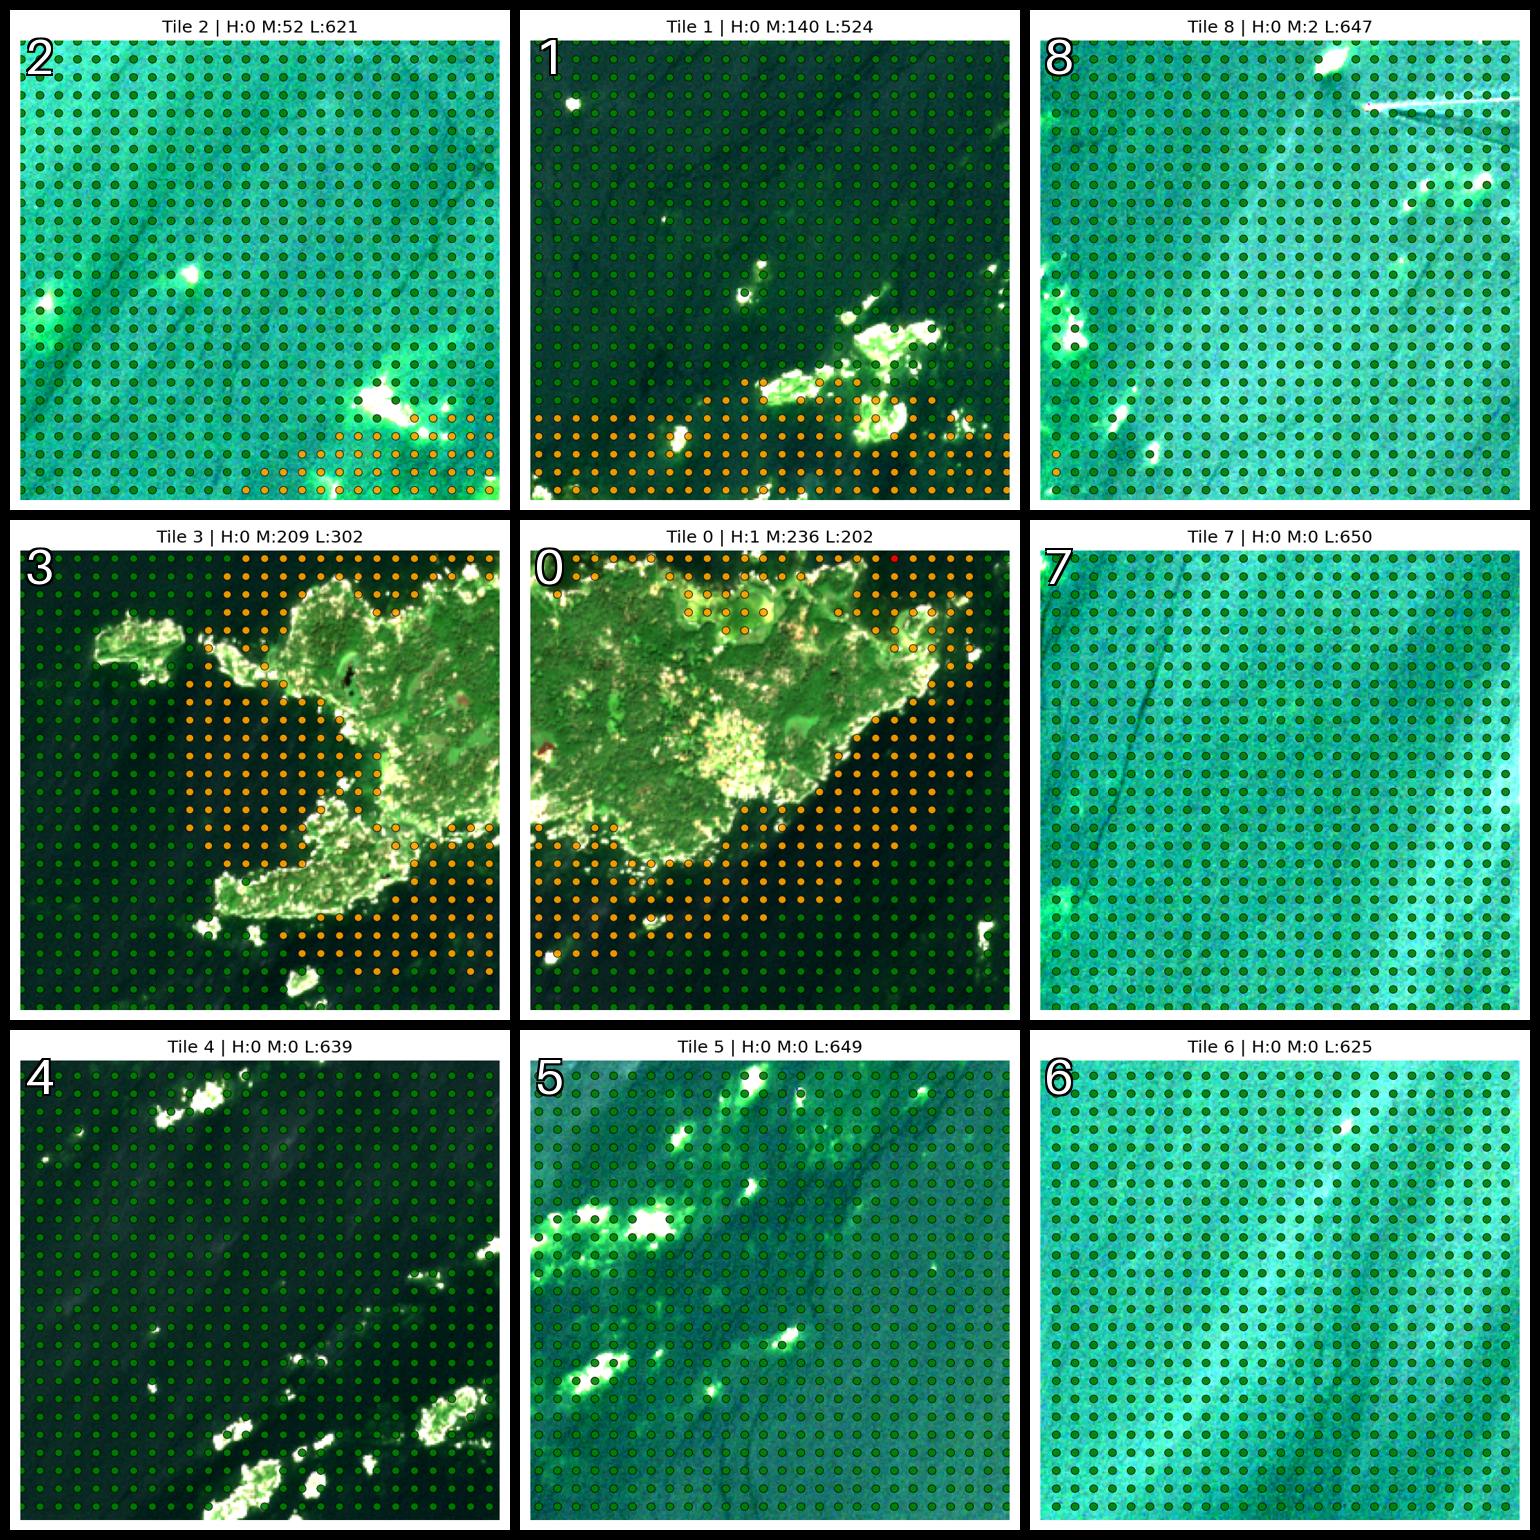

In [ ]:
root_folder = r"C:\Users\KostasPikounis\OneDrive_Inlecom_Personal\OneDrive - INLECOM\Amfitrite\task2\OWD\Sweden\metadata_v3"
csv_path = r"C:\Users\KostasPikounis\OneDrive_Inlecom_Personal\OneDrive - INLECOM\Amfitrite\task2\OWD\Sweden\junk.csv"

run_annotation_ui(root_folder, csv_path)